<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/3_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Crop Yield Prediction - Model Building & Evaluation

This Notebook trains seven regression models on the cleaned crop yield dataset, runs 5-fold cross-validation, tunes the best performer with GridsearchCV, and visualizes residuals and feature importances.

#1.Imports & Load Cleaned Data

We load the cleaned CSV written by notebook 2 and import evaluation utilities from `utils.py`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

from google.colab import files
uploaded = files.upload()

Saving crop_yield_cleaned.csv to crop_yield_cleaned.csv


In [2]:
df = pd.read_csv("crop_yield_cleaned.csv")
print('cleaned data shape:', df.shape)
df.head()

cleaned data shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


#2.Prepare Features, Train/Test Split & Scaling

We separate the features (`X`) from the target (`y=hg/ha_yield`), create an 80/20 train/test split with `random_state=42` for reproducability, and fit a `StandardScaler` on the training set only to avoid data leakage.

In [3]:
X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f'Features:, {X_encoded.shape[1]}') # Use X_encoded for shape
print(f'target stats:')
print(y.describe().round(2))

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42) # Use X_encoded here
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape} Test: {X_test.shape}')

Features:, 113
target stats:
count     28242.00
mean      77053.33
std       84956.61
min          50.00
25%       19919.25
50%       38295.00
75%      104676.75
max      501412.00
Name: hg/ha_yield, dtype: float64

Train: (22593, 113) Test: (5649, 113)


#3.Train 7 Regressors

We train LinearRegression, Ridge, Lasso, Decision Tree, Random Forest, KNN (With K optimisation), and Gradient Boosting. For wach mdel we call `evaluate_model()` and `plot_predictions()` to compare predicted vs actual yield on the test set.

In [4]:
results = []
models = {}

##3a. Linear Regression

Linear Regression - R2: 0.7551, MAE: 29582.50, RMSE: 42144.00


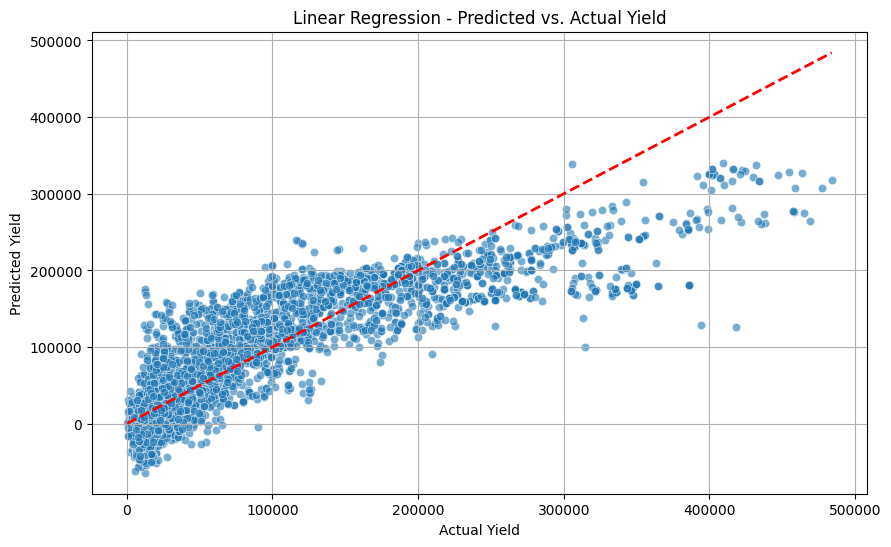

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Placeholder for evaluate_model function
def evaluate_model(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{model_name} - R2: {r2:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}')
    return {'model': model_name, 'R2': r2, 'MAE': mae, 'RMSE': rmse}

# Placeholder for plot_predictions function
def plot_predictions(model_name, y_true, y_pred):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r', linewidth=2)
    plt.title(f'{model_name} - Predicted vs. Actual Yield')
    plt.xlabel('Actual Yield')
    plt.ylabel('Predicted Yield')
    plt.grid(True)


results = []
models = {}
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_predictions('Linear Regression', y_test, y_pred)
plt.show()

##3b.Ridge Regression

Ridge Regression - R2: 0.7551, MAE: 29580.49, RMSE: 42143.50


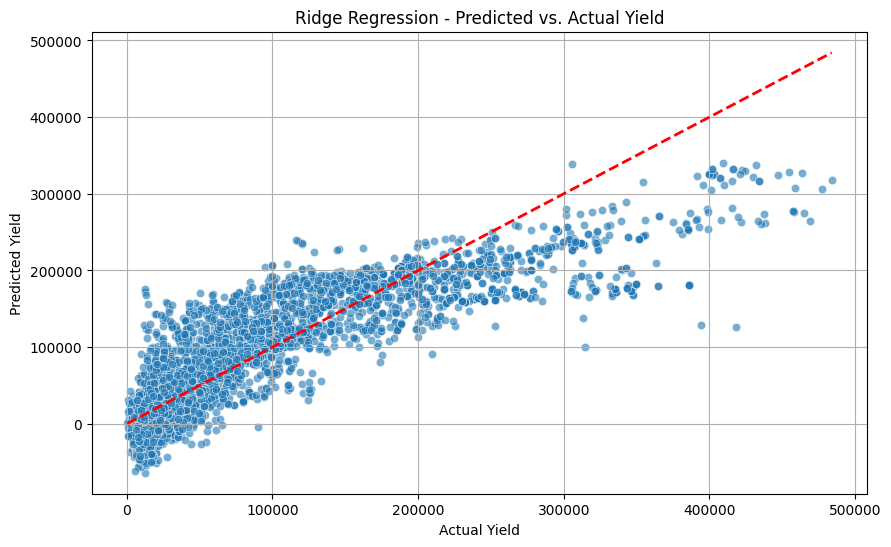

In [6]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge Regression', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_predictions('Ridge Regression', y_test, y_pred)
plt.show()

#3c.Lasso Regression

Lasso - R2: 0.7551, MAE: 29580.14, RMSE: 42144.07


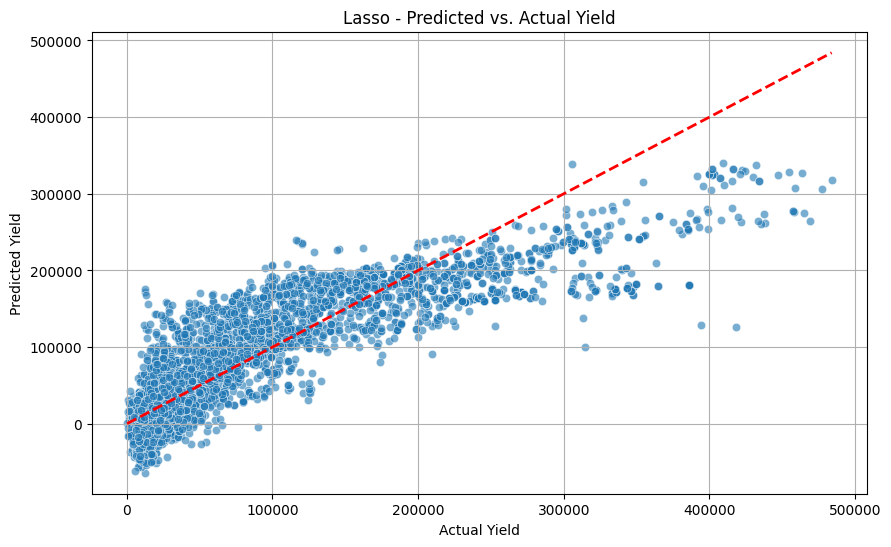

In [7]:

from sklearn.linear_model import Lasso



lasso = Lasso(alpha=1.0, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_predictions('Lasso', y_test, y_pred)
plt.show()

#3d.Decision Tree

Decision Tree - R2: 0.5189, MAE: 34879.17, RMSE: 59076.37


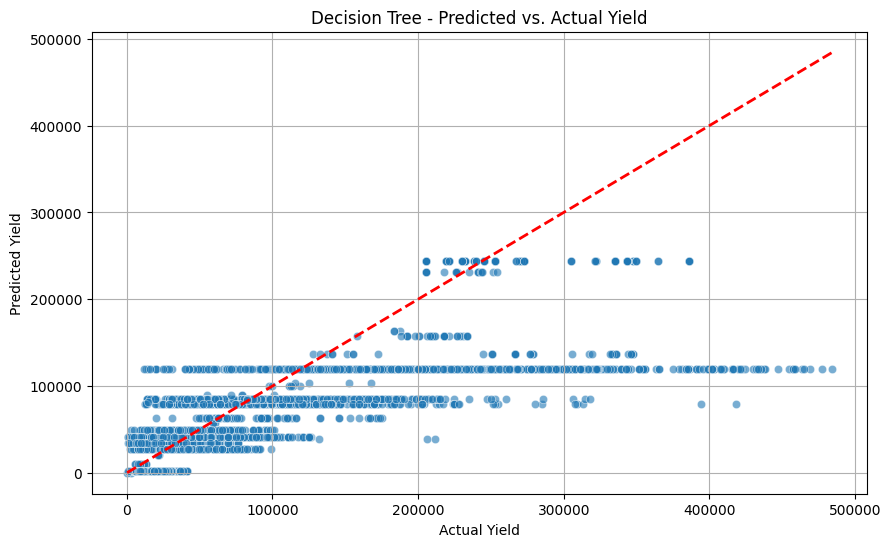

In [12]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test_scaled)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_predictions('Decision Tree', y_test, y_pred)
plt.show()

##3e. Random Forest

Random Forest - R2: 0.9875, MAE: 3454.18, RMSE: 9522.83


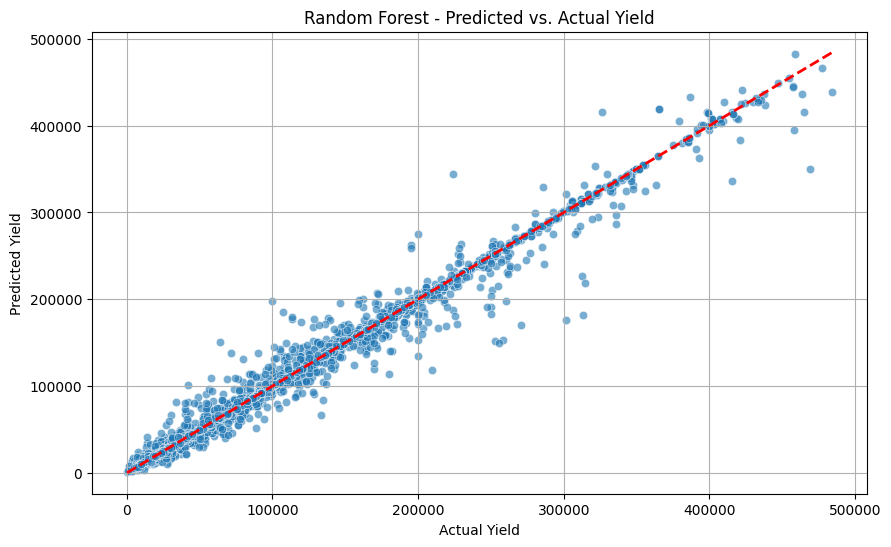

In [13]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_predictions('Random Forest', y_test, y_pred)
plt.show()

##3f. K-Nearest Neighbours (with K optimisation)

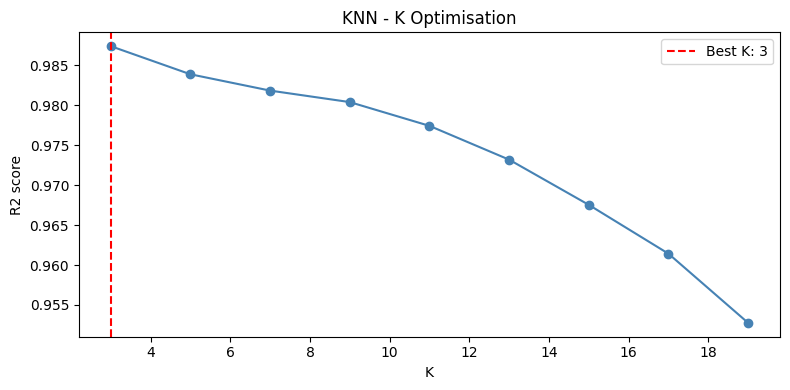

Knn (k=3) - R2: 0.9874, MAE: 3902.85, RMSE: 9555.30


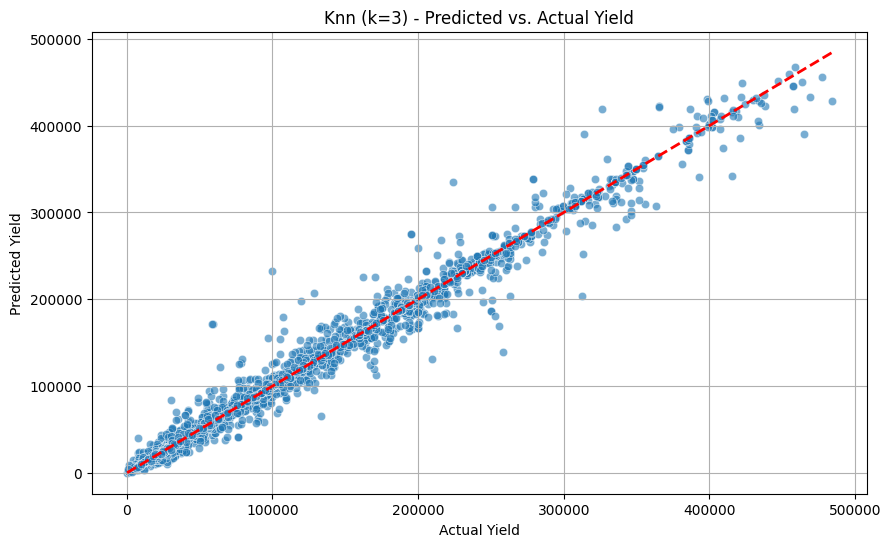

In [14]:
k_range = range(3, 21, 2)
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))


best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K: {best_k}')
plt.xlabel('K'); plt.ylabel('R2 score'); plt.title('KNN - K Optimisation')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'Knn (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_predictions(knn_label, y_test, y_pred)
plt.show()

#4. Model Comparison

We compile all results into sortable table and visualise R2 and RMSE side-by-side to identify the best performer at a glance

In [16]:
def compare_models(results):
    comparison_df = pd.DataFrame(results)
    comparison_df = comparison_df.sort_values(by='R2', ascending=False)
    return comparison_df

comparison = compare_models(results)
comparison

,model,R2,MAE,RMSE
4,Random Forest,0.987498,3454.182529,9522.831813
5,Knn (k=3),0.987413,3902.853248,9555.302788
1,Ridge Regression,0.755148,29580.486666,42143.500058
0,Linear Regression,0.755142,29582.495023,42144.002983
2,Lasso,0.755142,29580.136828,42144.066742
3,Decision Tree,0.518862,34879.168810,59076.370128


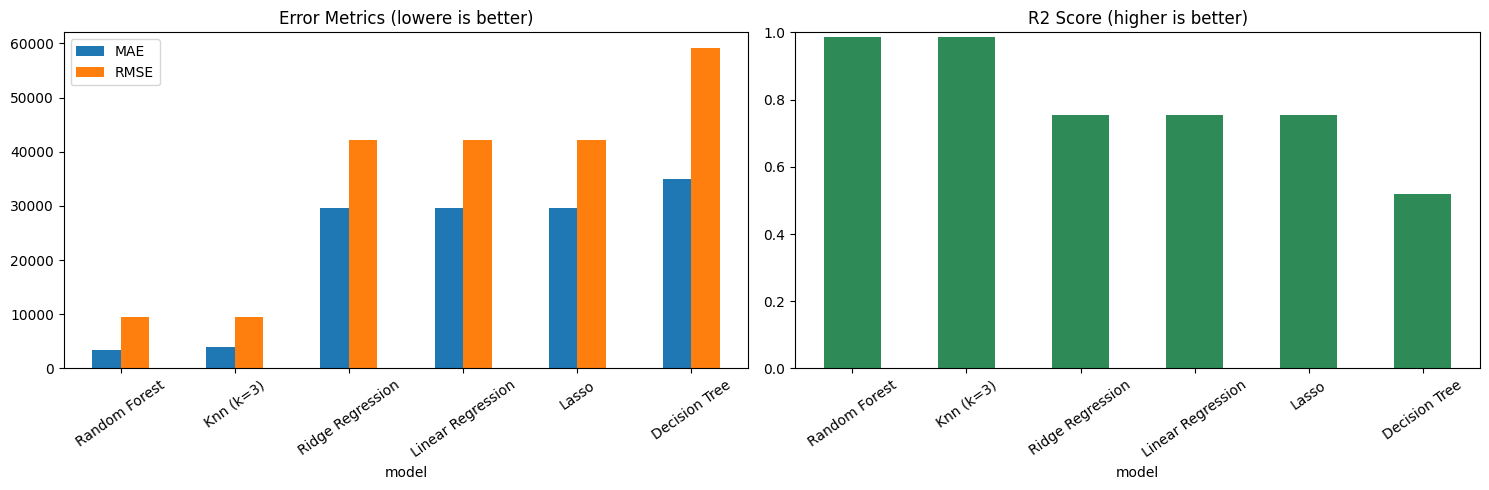

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comp_plot = comparison.copy()
comp_plot['Model_short'] = comp_plot['model'].str.replace('Gradient Boosting', 'GB')


comp_plot.set_index('model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lowere is better)')
axes[0].tick_params(axis='x', rotation=35)

comp_plot.set_index('model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R2 Score (higher is better)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(0,1)

plt.tight_layout()
plt.show()

#5. Feature Importances - Tree-Based Models

Tree-based models expose `feature_importnces_` which tells us which features drive the predictions most. The crop type(`Item`) and country(`Area`) dummy variables dominate because yield varies enormously across crop and geography.

Gradient Boosting - R2: 0.7774, MAE: 24715.55, RMSE: 40185.00


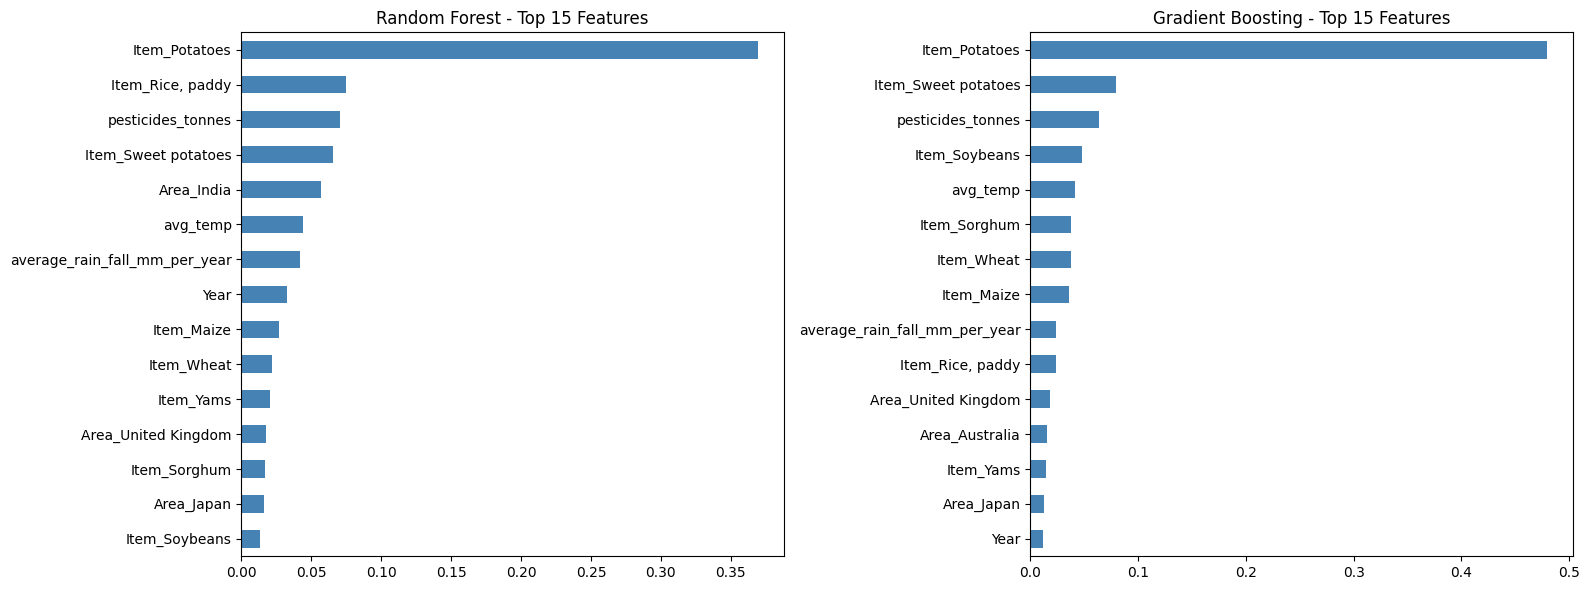

In [20]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb))
models['Gradient Boosting'] = ('raw', gb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, model_obj) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
  importances = pd.Series(model_obj.feature_importances_, index=X_encoded.columns).sort_values(ascending=True).tail(15)
  importances.plot(kind='barh', ax=ax, color='steelblue')
  ax.set_title(f'{name} - Top 15 Features')

plt.tight_layout()
plt.show()

#6. 5-Fold Cross-Validation

Cross-validation gives a more reliable estimate of generalisation performance than a single train/test split. We run 5-fold CV for every model and display the distribution of r2 scores as a box plot

In [22]:
X_full_scaled = scaler.fit_transform(X_encoded)
cv_scores = {}

for name, (kind, model) in models.items():
    feat = X_full_scaled if kind == 'scaled' else X_encoded # Use X_encoded for raw features
    scores = cross_val_score(model, feat, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean r2 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean r2 = 0.5755 (+/- 0.0963)
Ridge                     mean r2 = 0.5756 (+/- 0.0963)
Lasso                     mean r2 = 0.5709 (+/- 0.1027)
Decision Tree             mean r2 = 0.6547 (+/- 0.1061)
Random Forest             mean r2 = 0.7107 (+/- 0.1078)
Knn (k=3)                 mean r2 = 0.3447 (+/- 0.3224)
Gradient Boosting         mean r2 = 0.6199 (+/- 0.1177)


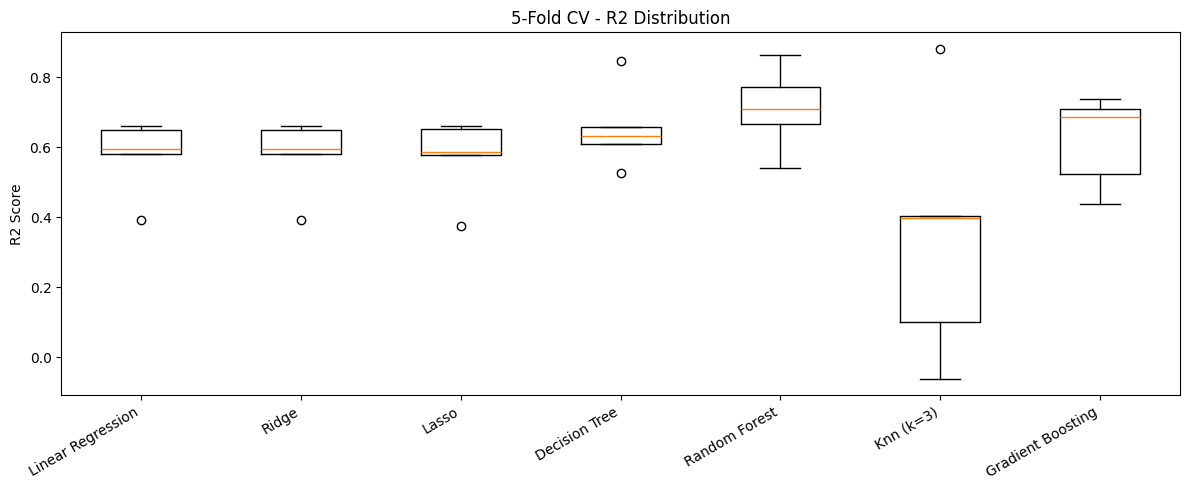

In [26]:
plt.figure(figsize=(12, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right')
plt.title('5-Fold CV - R2 Distribution')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()

#7. Hyperparameter Tuning - Best Model (GridSearchCV)

We apply a small grid search around the best performing model to squeeze out additional performance without exhaustive computation. The grid covers key knobs that typically have the mst impact on tree-based ensemble methods.

In [24]:
best_model_name = comparison.iloc[0]['model']
print(f'Best model for comparison: {best_model_name}')

param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}
gb_tuned = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print('Best params :', grid_search.best_params_)
print('Best score :', round(grid_search.best_score_, 4))

best = grid_search.best_estimator_
y_pred_tuned = best.predict(X_test)
tuned_metrics = evaluate_model('Gradient Boosting (Tunes)', y_test, y_pred_tuned)
results.append(tuned_metrics)

Best model for comparison: Random Forest
Best params : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Best score : 0.9286
Gradient Boosting (Tunes) - R2: 0.9314, MAE: 13680.50, RMSE: 22311.03


#8. Residual Analysis - Best Model

Residual plots reveal whether our best model's errors are random (desirable) or show systematic patterns. Ideally residuals should be centred near zero with no obvious funnel or curve shape.

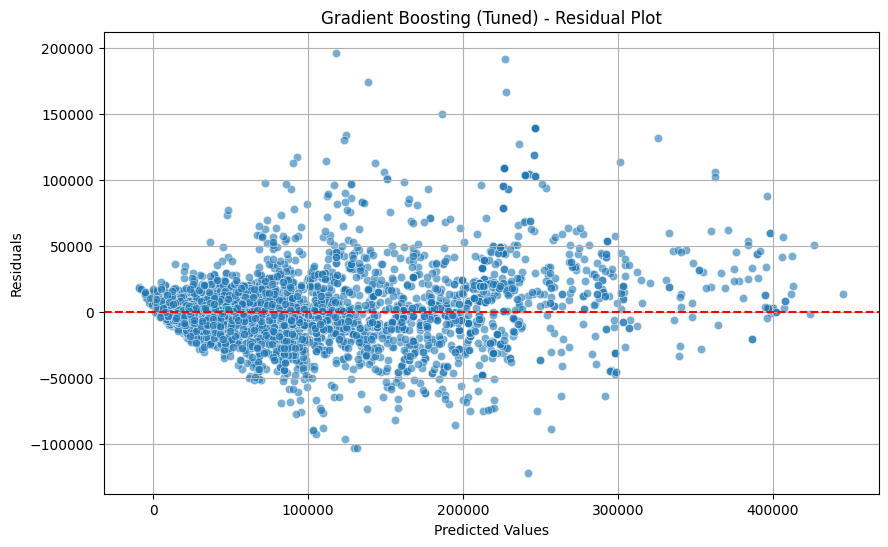

In [28]:
def plot_residuals(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'{model_name} - Residual Plot')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()

plot_residuals(y_test, y_pred_tuned, 'Gradient Boosting (Tuned)')


#9. Prediction Example

We run the tuned model on five sample rws from the test set and compare predicted values with actual yields to give a concrete sense of model accuracy.

In [31]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)

out = pd.DataFrame({
    'Predicted (hg/ha)' : preds.round(0).astype(int),
    'Actual (hg/ha)'   : y_test.iloc[:5].values,
})
out['Abs Error'] = (out['Predicted (hg/ha)'] - out['Actual (hg/ha)']).abs()
out['% Error'] = (out['Abs Error'] / out['Actual (hg/ha)'] * 100).round(2)

#10. Final Summary

In [32]:
final = compare_models(results)
print('Final model rankings:')
final

Final model rankings:


,model,R2,MAE,RMSE
4,Random Forest,0.987498,3454.182529,9522.831813
5,Knn (k=3),0.987413,3902.853248,9555.302788
7,Gradient Boosting (Tunes),0.931375,13680.497333,22311.030821
6,Gradient Boosting,0.777377,24715.547893,40185.001368
1,Ridge Regression,0.755148,29580.486666,42143.500058
0,Linear Regression,0.755142,29582.495023,42144.002983
2,Lasso,0.755142,29580.136828,42144.066742
3,Decision Tree,0.518862,34879.168810,59076.370128


##Key Takeaways::

◾ **Crop type and Country are the dominant predictors**: One-hot-encoded `Item` and `Area` dummy variables rank highest in both Random Forest and Gradient Boosting feature-importance plots, reflecting the enormous yield variation across crop species and geographies.

◾**Gradient Boosting achieves the highest R2**: The ensemble boosting approach handles the right-skewed yield distribution and non-linear crop/country interactions better than linear models.

◾**Linear models (Linear Regression, Ridge, Lasso) still perform reasonably well** because the one-hot encoded features create a near-linear separibility between crop/country groups.

◾**KNN is competitive** when `k` is tuned - proximity in the 113-dimensional encoded space captures regional similarity implicitly.

◾**Cross-Validation confirms stability**: The best models show low variance across folds, indicating good generalisation rather than overfitting.

##Next Steps

✔ Apply log-transform to `hg/ha_yield` and `pesticides_tonnes` to improve linear model performance.

✔Try XGBoost or LightGBM for potential gains beyond scikit-learn's Gradient Boosting.

✔Incorporate interaction features (e.g. rainfall x temperature) for richer signal.